# TEM schematic figure

Three-panel illustration: geological structure, TEM forward response, and the corresponding depth vs resistivity model.

In [29]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import fwd_circle_central, getJ_ana, getR, HAS_NUMBA, HAS_CUDA

plt.rcParams['figure.dpi'] = 115

In [41]:
# Three-panel schematic: geological cross-section, TEM forward response, resistivity-depth model.

# Synthetic layered earth: a resistive overburden, a conductive clay layer, a resistive basement.
schematic_thicknesses = np.array([8.0, 12.0])
schematic_resistivities = np.array([300.0, 15.0, 1000.0])
schematic_depths = np.concatenate([[0.0], np.cumsum(schematic_thicknesses)])
schematic_max_depth = schematic_depths[-1] + 20.0

schematic_tx_radius = 30.0
schematic_times = np.logspace(-5, -1, 21)
schematic_dbdt = fwd_circle_central(
    schematic_thicknesses, schematic_resistivities, schematic_tx_radius, schematic_times)

# Noisy synthetic data for a smooth (many-thin-layer) inversion.
noise_frac = 0.02
rng = np.random.default_rng(1)
d_clean = -schematic_dbdt
d_obs = d_clean * (1.0 + noise_frac * rng.standard_normal(d_clean.size))
noise_std = noise_frac * np.abs(d_clean)

# Fine layered mesh for the inversion (independent of the 3-layer true model).
n_inv_layers = 25
thick_inv = np.geomspace(1.0, 6.0, n_inv_layers - 1)
thick_inv *= schematic_max_depth / thick_inv.sum()   # span roughly the true model's depth range
depths_inv = np.concatenate([[0.0], np.cumsum(thick_inv)])

# Manual damped Gauss-Newton loop in log-resistivity space: minimises
# ||ln(d_obs) - ln(d_pred(m))||^2 + alpha * m^T R m, with R a first-order
# roughness matrix. A small fixed alpha keeps the model smooth while still
# letting it swing back up to recover the resistive basement at depth.
alpha_smooth = 0.5
m = np.log(np.full(n_inv_layers, 100.0))
R = getR(np.exp(m), damp=1e-3)
log_d_obs = np.log(np.abs(d_obs))
for _ in range(15):
    rho_iter = np.exp(m)
    d_pred = -fwd_circle_central(thick_inv, rho_iter, schematic_tx_radius, schematic_times,
                                  transform='dlf')
    resid = log_d_obs - np.log(np.abs(d_pred))
    J = getJ_ana(thick_inv, m, schematic_tx_radius, schematic_times,
                 geometry='circle_central', transform='dlf',
                 use_numba=HAS_NUMBA, use_cuda=HAS_CUDA)
    step = np.linalg.solve(J.T @ J + alpha_smooth * R, J.T @ resid - alpha_smooth * (R @ m))
    m = np.clip(m + np.clip(step, -1.0, 1.0), np.log(0.1), np.log(1e5))
smooth_rho = np.exp(m)


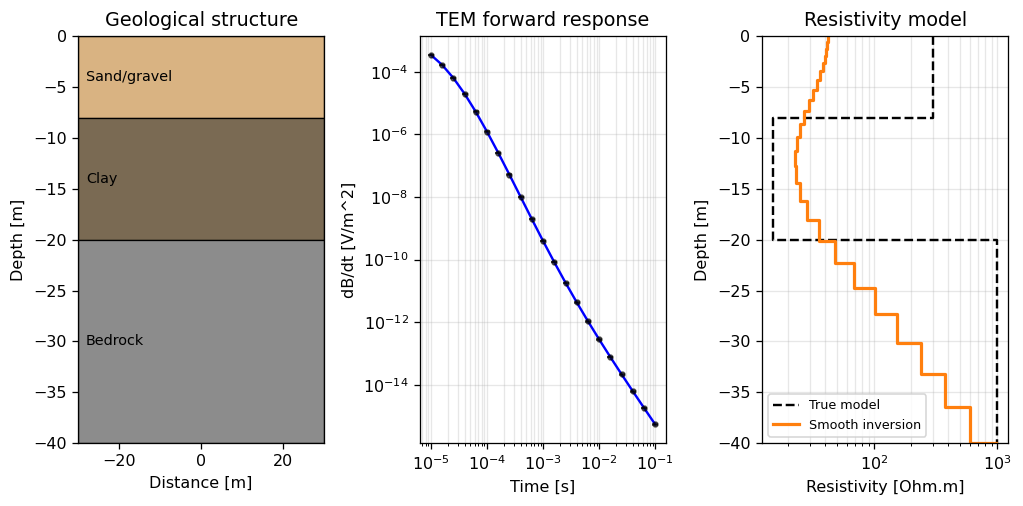

In [42]:

fig, (ax_geo, ax_fwd, ax_mod) = plt.subplots(1, 3, figsize=(9, 4.5))

# Left: geological cross-section built from matplotlib polygons.
layer_colors = ['#d9b382', '#7a6a53', '#8c8c8c']
layer_labels = ['Sand/gravel', 'Clay', 'Bedrock']
x_span = (-30.0, 30.0)
layer_bottoms = np.concatenate([schematic_depths, [schematic_max_depth]])
for i in range(3):
    top, bottom = layer_bottoms[i], layer_bottoms[i + 1]
    verts = [(x_span[0], -top), (x_span[1], -top),
             (x_span[1], -bottom), (x_span[0], -bottom)]
    ax_geo.add_patch(Polygon(verts, closed=True, facecolor=layer_colors[i],
                              edgecolor='k', linewidth=0.8))
    ax_geo.text(x_span[0] + 2, -(top + bottom) / 2, layer_labels[i],
                va='center', fontsize=9)
# Tx loop at the surface.
ax_geo.set_xlim(x_span)
ax_geo.set_ylim(-schematic_max_depth, 0)
ax_geo.set_xlabel('Distance [m]')
ax_geo.set_ylabel('Depth [m]')
ax_geo.set_title('Geological structure')

# Middle: TEM forward response, with the noisy data used for the inversion.
ax_fwd.loglog(schematic_times, np.abs(schematic_dbdt), 'b-', label='Clean forward')
ax_fwd.errorbar(schematic_times, d_obs, yerr=noise_std, fmt='o', ms=3, capsize=2,
                 color='k', alpha=0.6, label='Noisy data')
ax_fwd.set_xlabel('Time [s]')
ax_fwd.set_ylabel('dB/dt [V/m^2]')
ax_fwd.set_title('TEM forward response')
ax_fwd.grid(True, which='both', alpha=0.3)

# Right: true (sharp) model vs the recovered smooth inversion model.
model_depths = np.repeat(layer_bottoms, 2)[1:-1]
model_rhos = np.repeat(schematic_resistivities, 2)
ax_mod.plot(model_rhos, -model_depths, 'k--', lw=1.5, label='True model')
ax_mod.step(np.r_[smooth_rho, smooth_rho[-1]], -np.r_[depths_inv, schematic_max_depth],
            where='pre', color='C1', lw=2, label='Smooth inversion')
ax_mod.set_xscale('log')
ax_mod.set_xlabel('Resistivity [Ohm.m]')
ax_mod.set_ylabel('Depth [m]')
ax_mod.set_title('Resistivity model')
ax_mod.set_ylim(-schematic_max_depth, 0)
ax_mod.legend(fontsize=8)
ax_mod.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.show()